<a id='II-5'></a>
## **5. Exploratory Data Analysis & Visualization**

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pylab import rcParams

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})
sns.set_palette('husl')

import pickle
with open('outputs/processed/cleaned_data.pkl', 'rb') as f:
    data = pickle.load(f)

df            = data['df']
OS_daily      = data['OS_daily']
monthly_sales = data['monthly_sales']

print(" Data loaded successfully!")
print(f"   monthly_sales: {len(monthly_sales)} rows")
print(f"   OS_daily:      {len(OS_daily)} rows")

 Data loaded successfully!
   monthly_sales: 48 rows
   OS_daily:      1148 rows


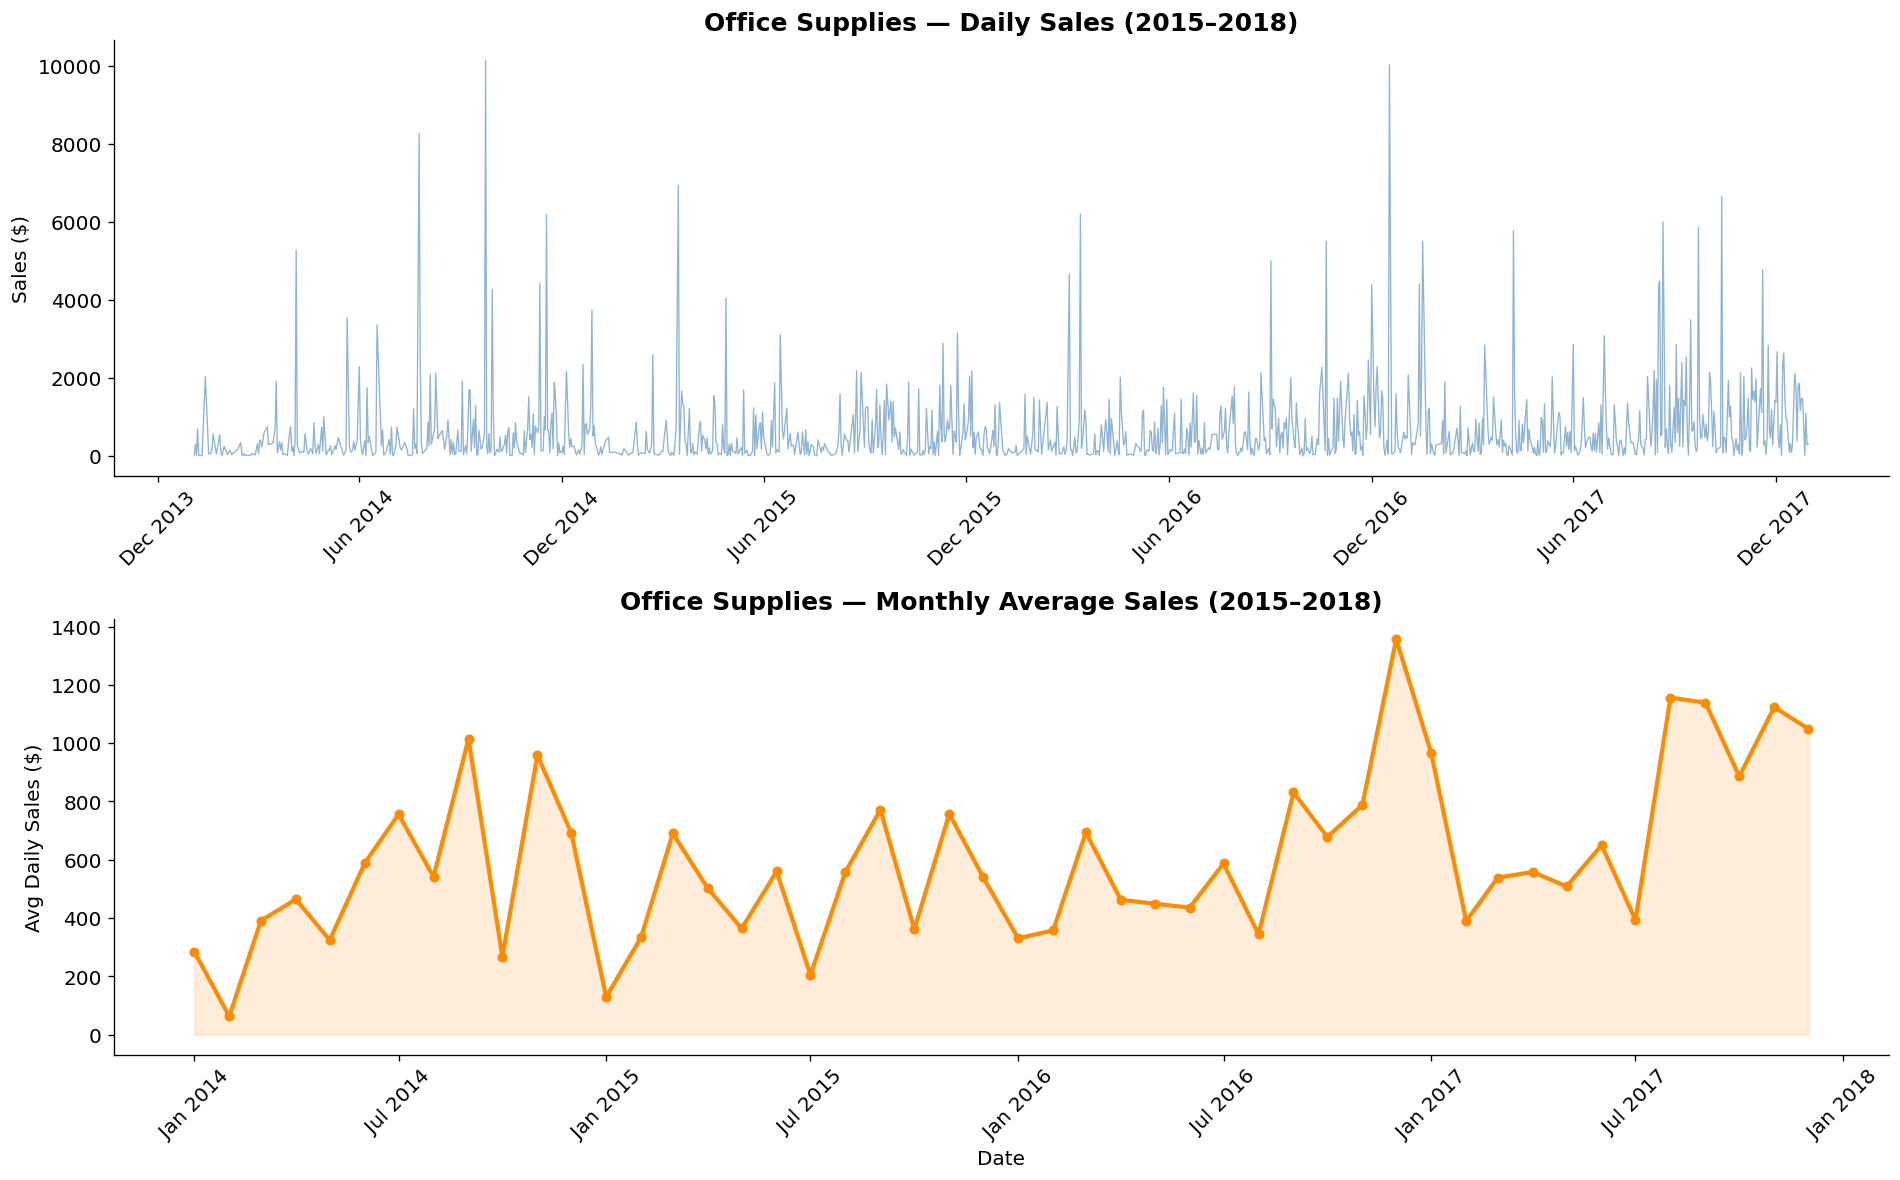

In [6]:
# ── 5.1 Raw daily sales ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Daily
axes[0].plot(OS_daily.index, OS_daily['Sales'], alpha=0.6, color='steelblue', linewidth=0.8)
axes[0].set_title('Office Supplies — Daily Sales (2015–2018)', fontsize=15, fontweight='bold')
axes[0].set_ylabel('Sales ($)')
axes[0].set_xlabel('')

# Monthly average
axes[1].plot(monthly_sales.index, monthly_sales.values, color='darkorange', linewidth=2.5, marker='o', markersize=5)
axes[1].fill_between(monthly_sales.index, monthly_sales.values, alpha=0.15, color='darkorange')
axes[1].set_title('Office Supplies — Monthly Average Sales (2015–2018)', fontsize=15, fontweight='bold')
axes[1].set_ylabel('Avg Daily Sales ($)')
axes[1].set_xlabel('Date')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

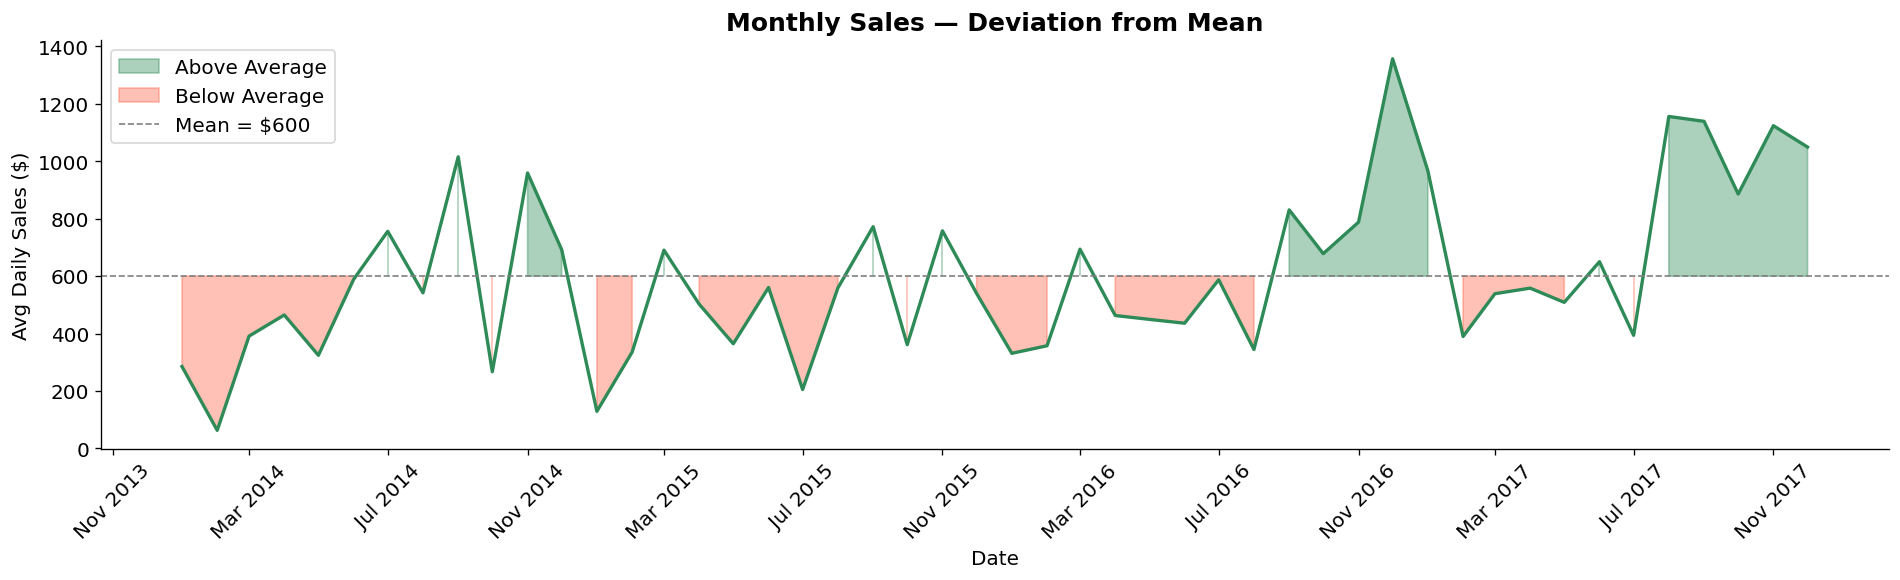

In [7]:
# ── 5.2 Two-sided fill plot to emphasize variation ──────────────────────────
x = monthly_sales.index
y = monthly_sales.values
mean_val = y.mean()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(x, y, color='seagreen', linewidth=2)
ax.fill_between(x, y1=mean_val, y2=y, where=(y >= mean_val), alpha=0.4, color='seagreen', label='Above Average')
ax.fill_between(x, y1=mean_val, y2=y, where=(y < mean_val), alpha=0.4, color='tomato', label='Below Average')
ax.axhline(mean_val, color='gray', linestyle='--', linewidth=1, label=f'Mean = ${mean_val:.0f}')
ax.set_title('Monthly Sales — Deviation from Mean', fontsize=15, fontweight='bold')
ax.set_ylabel('Avg Daily Sales ($)')
ax.set_xlabel('Date')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
plt.tight_layout()
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_10264\3329805105.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='year', y='Sales', data=OS_daily_plot, ax=axes[0], palette='Set2')
C:\Users\Dell\AppData\Local\Temp\ipykernel_10264\3329805105.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


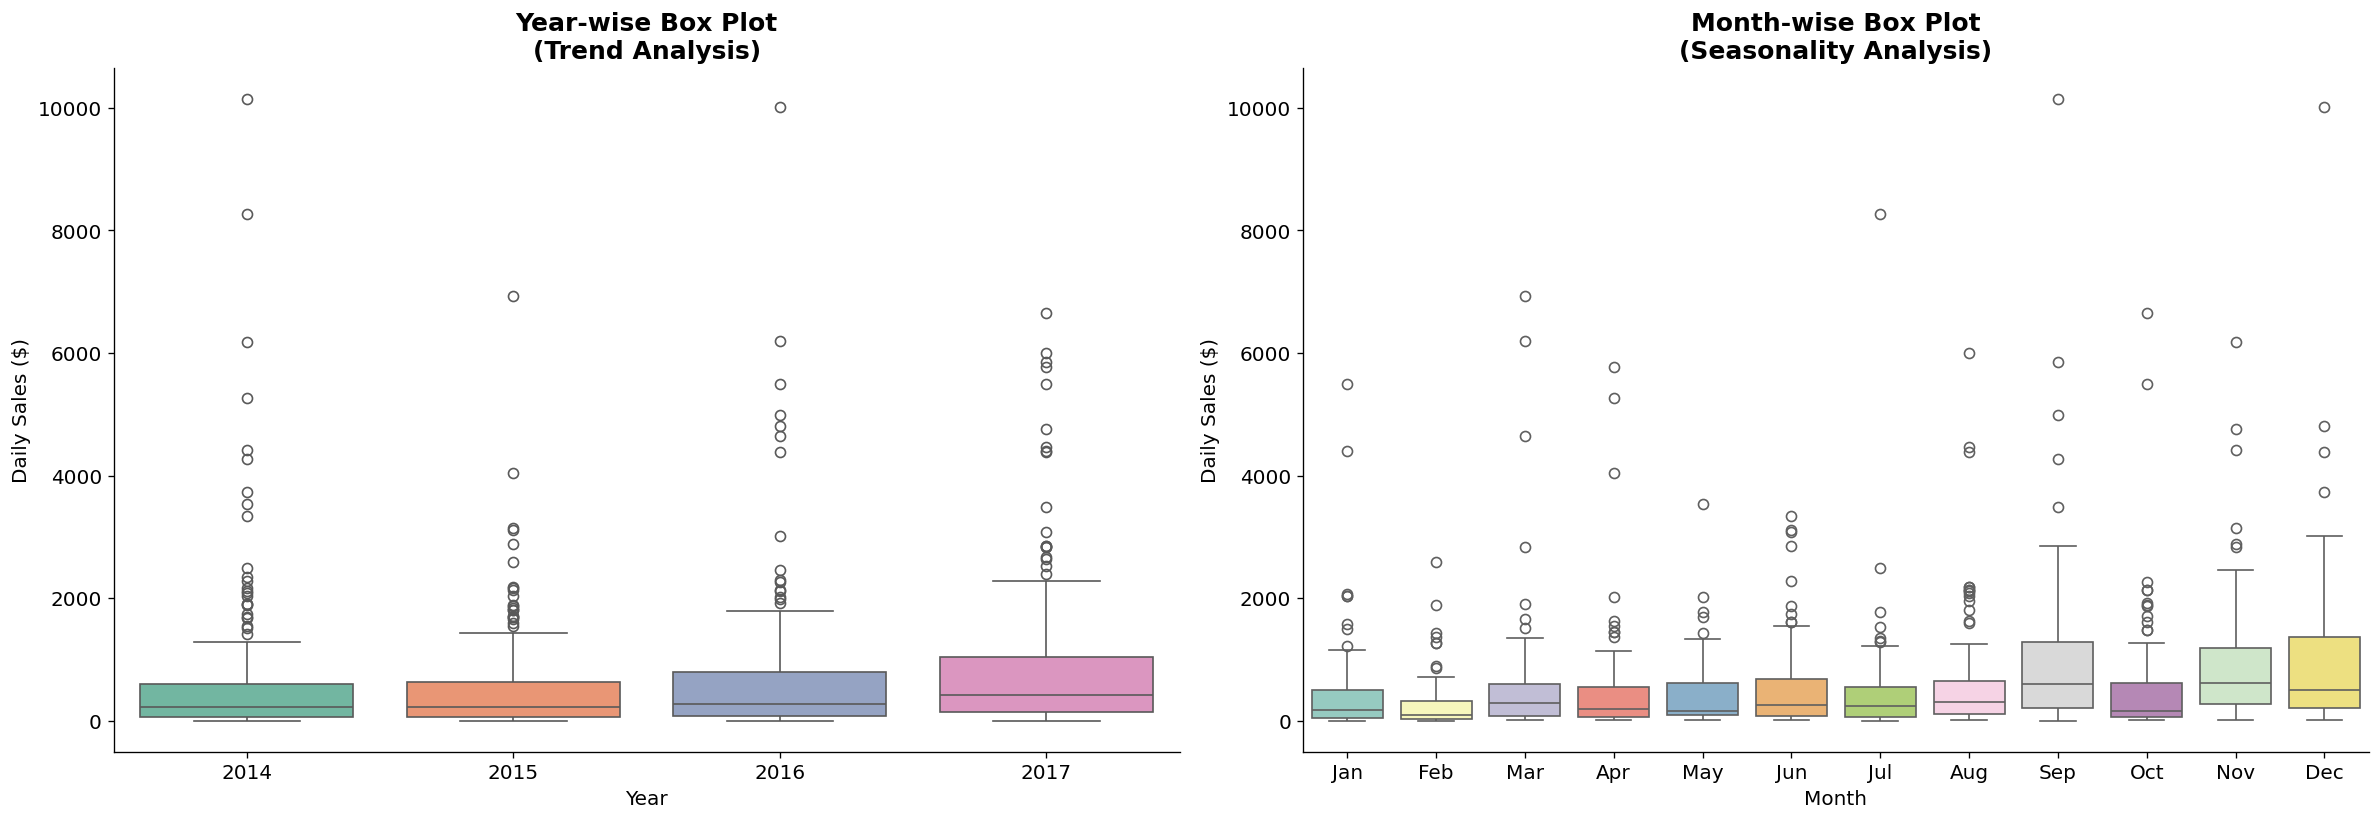

📊 Observations:
  • Year-wise: Sales show an upward trend from 2015 to 2018
  • Month-wise: Q4 (Nov–Dec) consistently shows higher sales — holiday effect


In [8]:
# ── 5.3 Year-wise & Month-wise Box Plots ────────────────────────────────────
# Add year/month columns to daily data
OS_daily_plot = OS_daily.copy()
OS_daily_plot['year'] = OS_daily_plot.index.year
OS_daily_plot['month'] = OS_daily_plot.index.strftime('%b')
OS_daily_plot['month_num'] = OS_daily_plot.index.month

# Month order for correct sorting
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Year-wise box plot (Trend)
sns.boxplot(x='year', y='Sales', data=OS_daily_plot, ax=axes[0], palette='Set2')
axes[0].set_title('Year-wise Box Plot\n(Trend Analysis)', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Daily Sales ($)')

# Month-wise box plot (Seasonality)
sns.boxplot(
    x='month', y='Sales',
    data=OS_daily_plot,
    order=month_order,
    ax=axes[1],
    palette='Set3'
)
axes[1].set_title('Month-wise Box Plot\n(Seasonality Analysis)', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Daily Sales ($)')

plt.tight_layout()
plt.show()

print("📊 Observations:")
print("  • Year-wise: Sales show an upward trend from 2015 to 2018")
print("  • Month-wise: Q4 (Nov–Dec) consistently shows higher sales — holiday effect")

In [10]:
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

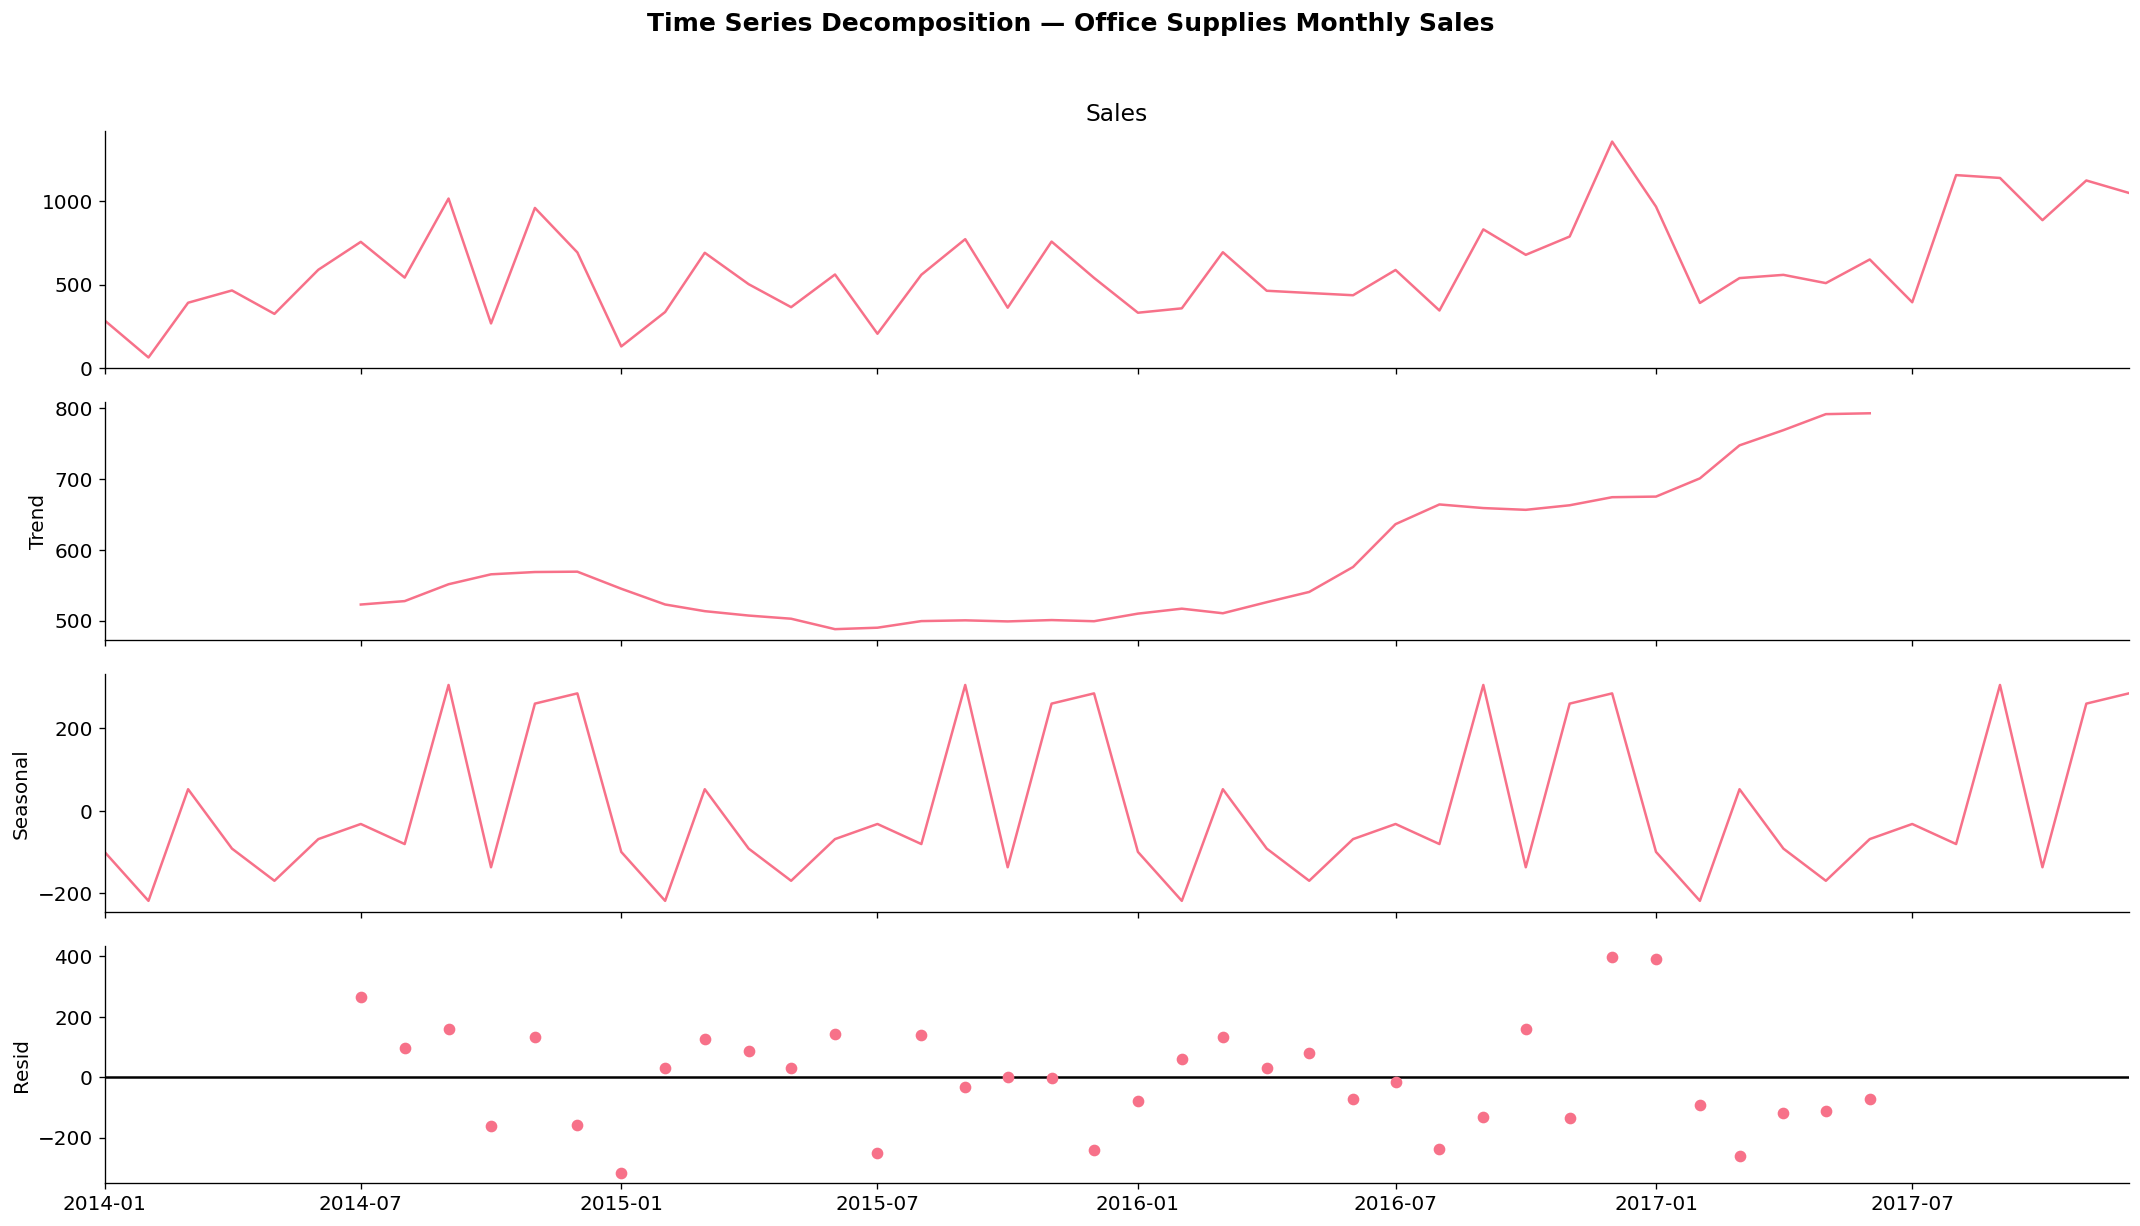

📊 Decomposition Insights:
  • Trend: General upward trend visible over 4 years
  • Seasonal: Clear yearly pattern — peaks around Nov–Dec
  • Residual: Random noise around zero — well-captured by the model


In [11]:
# ── 5.4 Time Series Decomposition ───────────────────────────────────────────
rcParams['figure.figsize'] = 18, 10

decomposition = seasonal_decompose(monthly_sales, model='additive', period=12)
fig = decomposition.plot()
fig.suptitle('Time Series Decomposition — Office Supplies Monthly Sales',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Reset figure size
plt.rcParams['figure.figsize'] = (14, 6)

print("📊 Decomposition Insights:")
print(f"  • Trend: General upward trend visible over 4 years")
print(f"  • Seasonal: Clear yearly pattern — peaks around Nov–Dec")
print(f"  • Residual: Random noise around zero — well-captured by the model")

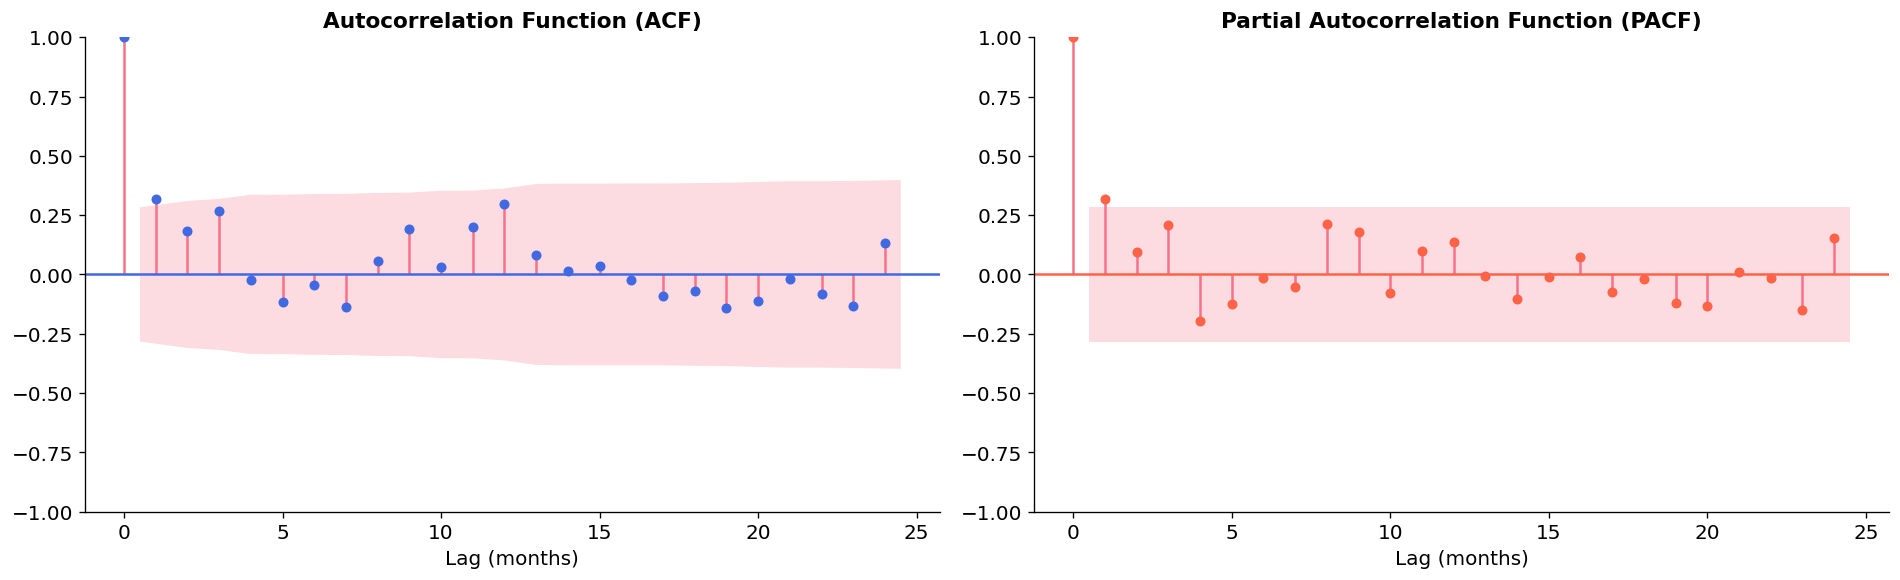

📊 ACF/PACF Interpretation:
  • ACF: Slowly decaying autocorrelation → series likely non-stationary
  • PACF: Significant spike at lag 1 → AR(1) component likely
  • Seasonal spikes at lag 12 → seasonal differencing may be needed


In [12]:
# ── 5.5 ACF & PACF Plots ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(monthly_sales, lags=24, ax=axes[0], color='royalblue')
axes[0].set_title('Autocorrelation Function (ACF)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Lag (months)')

plot_pacf(monthly_sales, lags=24, ax=axes[1], method='ywm', color='tomato')
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Lag (months)')

plt.tight_layout()
plt.show()

print("📊 ACF/PACF Interpretation:")
print("  • ACF: Slowly decaying autocorrelation → series likely non-stationary")
print("  • PACF: Significant spike at lag 1 → AR(1) component likely")
print("  • Seasonal spikes at lag 12 → seasonal differencing may be needed")

In [13]:
import pickle
with open('outputs/processed/cleaned_data.pkl', 'rb') as f:
    data = pickle.load(f)
monthly_sales = data['monthly_sales']
OS_daily      = data['OS_daily']